In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional, Union

import scipy

from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.linalg import transformation_matrix
from py_mods.src.external.DIRAC_ME import build_4c_one_Fock_from_h5, build_S_V_W_T_from_h5
from py_mods.src.algebra.quaternion import quaternion_to_matrix


In [2]:
checkpoint_files = [
    "files/H_checkpoint.h5",
    "files/He_checkpoint.h5",
    "files/Ne_checkpoint.h5",
]
for checkpoint_file in checkpoint_files:
    F_0 = build_4c_one_Fock_from_h5(checkpoint_file)
    S, V, W, T = build_S_V_W_T_from_h5(checkpoint_file)

    with h5py.File(checkpoint_file, "r") as f:
        fockarra = np.asarray(f["result/operators/ao_matrices/ONEFOCK"][()])
        overlap = np.asarray(f["result/operators/ao_matrices/OVERLAP TFFT"][()])

    n_bas = int((np.sqrt(1 + 8 * len(overlap)) - 1) / 2)

    focsquare = fockarra.reshape(4, n_bas, n_bas)  # or manually, but this is convenient
    f0, f1, f2, f3 = focsquare[0], focsquare[1], focsquare[2], focsquare[3]
    Qf = quaternion_to_matrix(f0, f1, f2, f3)

    print(
        f"For Checkpoint file '{checkpoint_file}', extracted F == recostructed F: {np.allclose(Qf, F_0)}"
    )

For Checkpoint file 'files/H_checkpoint.h5', extracted F == recostructed F: True
For Checkpoint file 'files/He_checkpoint.h5', extracted F == recostructed F: True
For Checkpoint file 'files/Ne_checkpoint.h5', extracted F == recostructed F: True


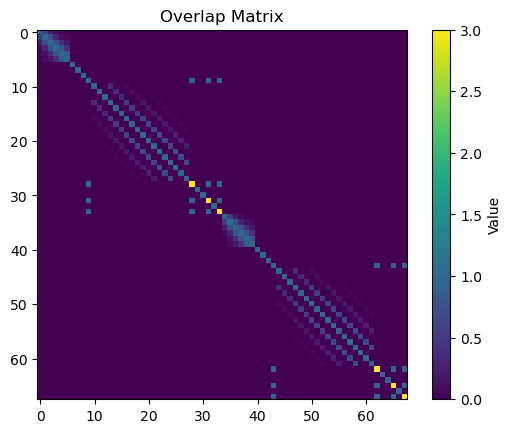

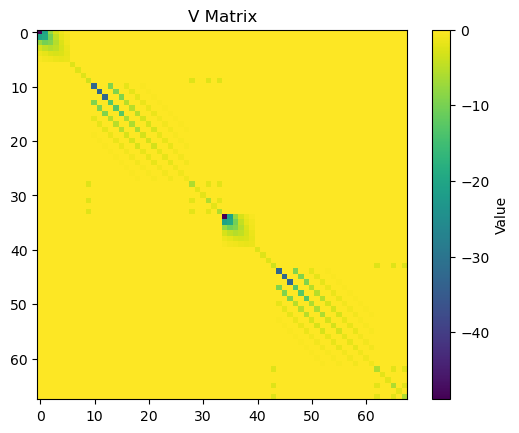

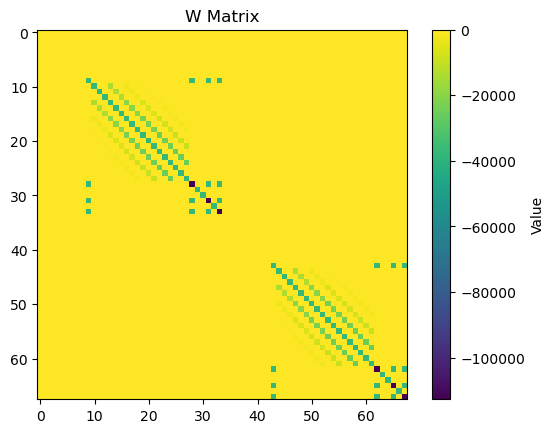

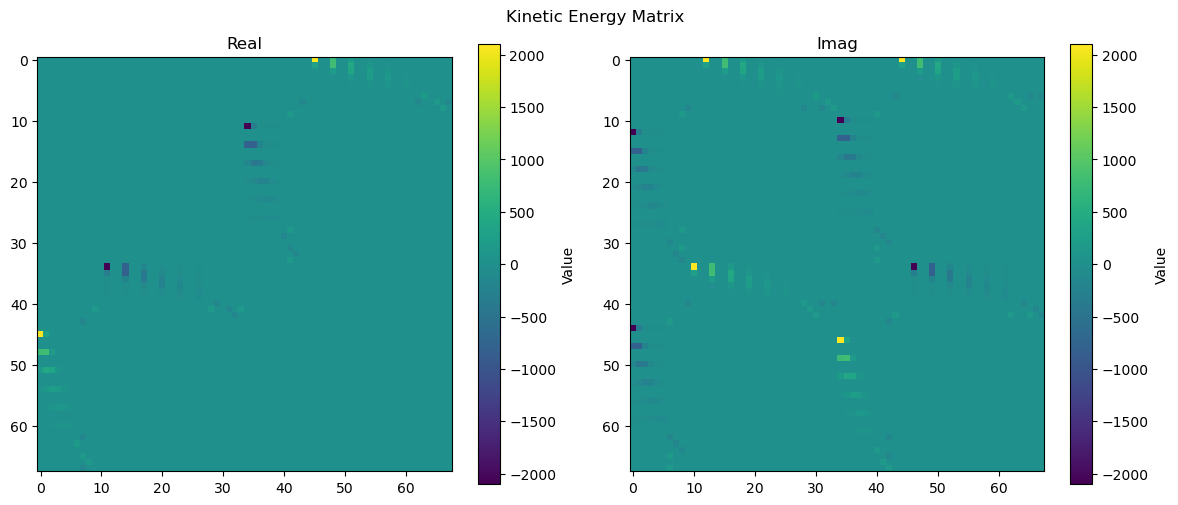

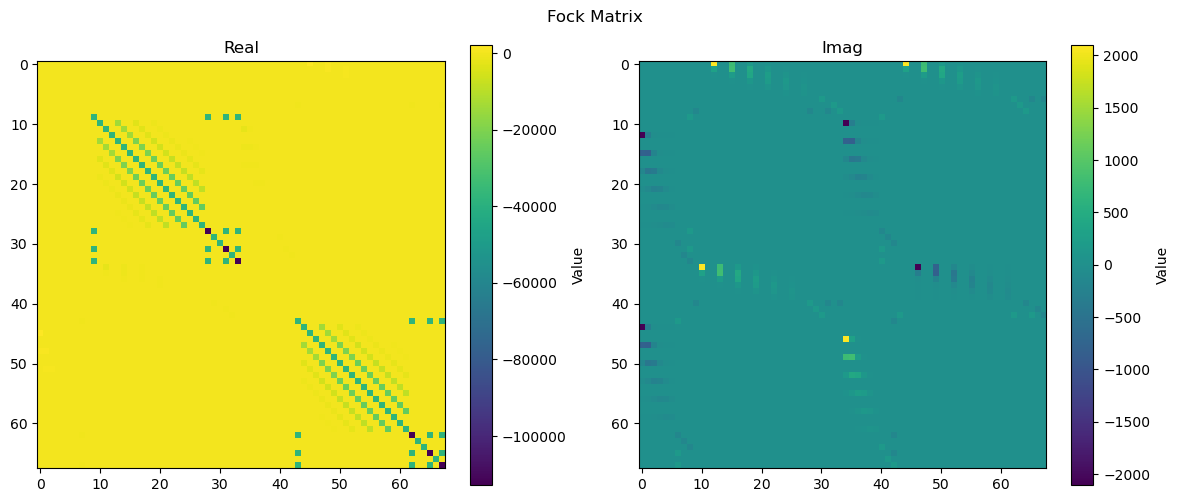

In [3]:
h5_filename = "files/He_checkpoint.h5"
F_0 = build_4c_one_Fock_from_h5(h5_filename)
S, V, W, T = build_S_V_W_T_from_h5(h5_filename)

plot_map(S, title="Overlap Matrix")
plot_map(V, title="V Matrix")
plot_map(W, title="W Matrix")
plot_map(T, title="Kinetic Energy Matrix")
plot_map(F_0, title="Fock Matrix")

In [4]:
e, w = scipy.linalg.eigh(S[:9, :9])
for i, ev in enumerate(sorted((e.real))[::-1]):
    print(f"Eigenvalue {i}: {ev:.5f}")

Eigenvalue 0: 2.94063
Eigenvalue 1: 1.62709
Eigenvalue 2: 1.00000
Eigenvalue 3: 1.00000
Eigenvalue 4: 1.00000
Eigenvalue 5: 0.84922
Eigenvalue 6: 0.39083
Eigenvalue 7: 0.14982
Eigenvalue 8: 0.04241


We can compare it with the result from the $\mathrm{He}$ output:


 |$SC_{eigenv}$| Value|
 | - | - |   
 |$ 1$|$   2.9406 $|
 |$ 2$|$   1.6270 $|
 |$ 3$|$   0.9999 $|
 |$ 4$|$   0.9999 $|
 |$ 5$|$   0.9999 $|
 |$ 6$|$   0.8492 $|
 |$ 7$|$   0.3908 $|
 |$ 8$|$   0.1498 $|
 |$ 9$|$   0.0424 $|

Which fits. And also compute them for the large component:

In [5]:
e, w = scipy.linalg.eigh(S[9:34, 9:34])

for i, ev in enumerate(sorted((e.real))[::-1]):
    print(f"Eigenvalue {i}: {ev:.5f}")

Eigenvalue 0: 5.64575
Eigenvalue 1: 2.37240
Eigenvalue 2: 2.37240
Eigenvalue 3: 2.37240
Eigenvalue 4: 2.00000
Eigenvalue 5: 2.00000
Eigenvalue 6: 1.56695
Eigenvalue 7: 1.56695
Eigenvalue 8: 1.56695
Eigenvalue 9: 1.02690
Eigenvalue 10: 1.02690
Eigenvalue 11: 1.02690
Eigenvalue 12: 1.00000
Eigenvalue 13: 1.00000
Eigenvalue 14: 1.00000
Eigenvalue 15: 0.61714
Eigenvalue 16: 0.61714
Eigenvalue 17: 0.61714
Eigenvalue 18: 0.35425
Eigenvalue 19: 0.30462
Eigenvalue 20: 0.30462
Eigenvalue 21: 0.30462
Eigenvalue 22: 0.11200
Eigenvalue 23: 0.11200
Eigenvalue 24: 0.11200


And on the small component

 |$SC_{eigenv}$| Value|
 | - | - |  
 | $ 1$ |$  5.6457$ |
 | $ 2$ |$  2.3724$ |
 | $ 3$ |$  2.3724$ |
 | $ 4$ |$  2.3724$ |
 | $ 5$ |$  1.9999$ |
 | $ 6$ |$  1.9999$ |
 | $ 7$ |$  1.5669$ |
 | $ 8$ |$  1.5669$ |
 | $ 9$ |$  1.5669$ |
 | $10$ |$  1.0268$ |
 | $11$ |$  1.0268$ |
 | $12$ |$  1.0268$ |
 | $13$ |$ 0.99999$ |
 | $14$ |$ 0.99999$ |
 | $15$ |$ 0.99999$ |
 | $16$ |$ 0.61714$ |
 | $17$ |$ 0.61714$ |
 | $18$ |$ 0.61714$ |
 | $19$ |$ 0.35424$ |
 | $20$ |$ 0.30461$ |
 | $21$ |$ 0.30461$ |
 | $22$ |$ 0.30461$ |
 | $23$ |$ 0.11199$ |
 | $24$ |$ 0.11199$ |
 | $25$ |$ 0.11199$ |

 Which also fit. Therefore, it is tempting to compute the transformation matrix $X$, in order to transform to the orthogonal representation of the basis, and diagonalize as in the regular SCF.

In [6]:
X = transformation_matrix(S)

# plot_map(X)

F_p = X.T @ F_0 @ X
np.allclose(F_p, F_p.conj().T)

True

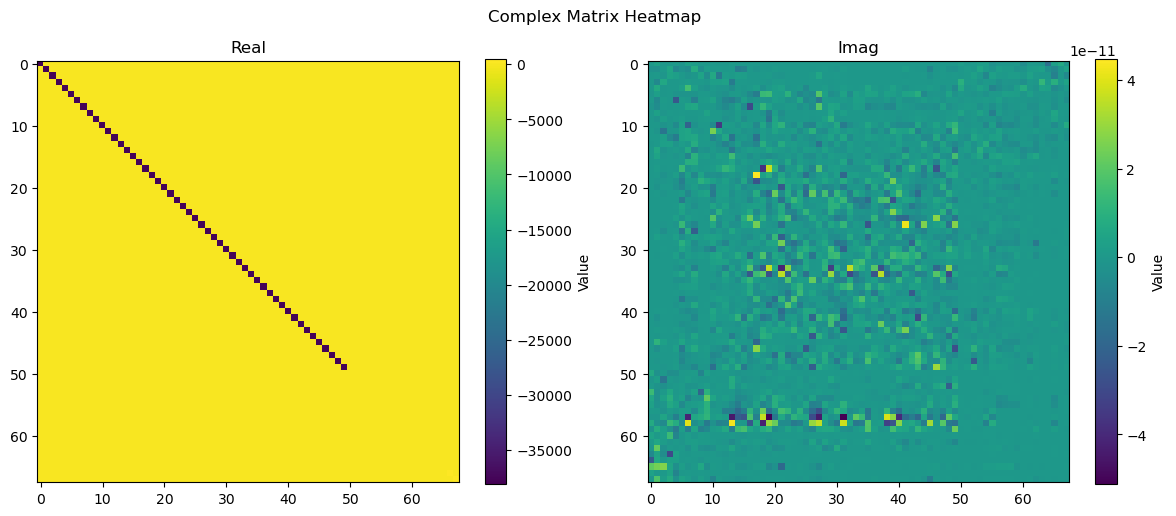

In [7]:
# plot_map(F_p)

e, w = scipy.linalg.eig(F_p)
e2, w2 = scipy.linalg.eig(F_0, S)  # to test it out

idx = np.argsort(e)
e = e[idx]
w = w[:, idx]

F_diag = np.linalg.inv(w) @ F_p @ w
plot_map(F_diag)

In [8]:
maxdiff = np.max(np.abs(np.array(sorted((e.real))) - np.array(sorted((e2.real)))))
print(
    f"Max difference between eigenvalues of X.T @ F_0 @ X and generalized(F_0,S): {maxdiff}\n"
)

for i, ev in enumerate(sorted((e.real))):
    if i % 2 == 0:
        print(f"Eigenvalue {i//2}: {ev:.5f}")

Max difference between eigenvalues of X.T @ F_0 @ X and generalized(F_0,S): 3.637978807091713e-10

Eigenvalue 0: -38065.65307
Eigenvalue 1: -37653.11328
Eigenvalue 2: -37590.88249
Eigenvalue 3: -37590.88249
Eigenvalue 4: -37583.46032
Eigenvalue 5: -37569.55974
Eigenvalue 6: -37569.55974
Eigenvalue 7: -37566.05752
Eigenvalue 8: -37565.71027
Eigenvalue 9: -37563.02433
Eigenvalue 10: -37563.02433
Eigenvalue 11: -37562.83058
Eigenvalue 12: -37562.83058
Eigenvalue 13: -37560.68391
Eigenvalue 14: -37560.37850
Eigenvalue 15: -37560.37850
Eigenvalue 16: -37559.65010
Eigenvalue 17: -37559.65010
Eigenvalue 18: -37559.65010
Eigenvalue 19: -37559.53010
Eigenvalue 20: -37559.12990
Eigenvalue 21: -37559.12990
Eigenvalue 22: -37558.76697
Eigenvalue 23: -37558.47575
Eigenvalue 24: -37558.47575
Eigenvalue 25: -1.99966
Eigenvalue 26: -0.39581
Eigenvalue 27: 0.78030
Eigenvalue 28: 0.78054
Eigenvalue 29: 0.78054
Eigenvalue 30: 1.91831
Eigenvalue 31: 12.97273
Eigenvalue 32: 67.12647
Eigenvalue 33: 428.4123

And expected result is: 
|n| Eigenvalue|
|-|-|
|$    1$|$        -38065.6530726$| 
|$    2$|$        -37653.1132843$| 
|$    3$|$        -37590.8824850$| 
|$    4$|$        -37590.8824850$| 
|$    5$|$        -37583.4603228$| 
|$    6$|$        -37569.5597401$| 
|$    7$|$        -37569.5597401$| 
|$    8$|$        -37566.0575194$| 
|$    9$|$        -37565.7102653$| 
|$   10$|$        -37563.0243338$| 
|$   11$|$        -37563.0243338$| 
|$   12$|$        -37562.8305777$| 
|$   13$|$        -37562.8305777$| 
|$   14$|$        -37560.6839148$| 
|$   15$|$        -37560.3785022$| 
|$   16$|$        -37560.3785022$| 
|$   17$|$        -37559.6500952$| 
|$   18$|$        -37559.6500952$| 
|$   19$|$        -37559.6500952$| 
|$   20$|$        -37559.5300980$| 
|$   21$|$        -37559.1299013$| 
|$   22$|$        -37559.1299013$| 
|$   23$|$        -37558.7669715$| 
|$   24$|$        -37558.4757513$| 
|$   25$|$        -37558.4757513$| 
|$   26$|$            -1.9996609$| 
|$   27$|$            -0.3958139$| 
|$   28$|$             0.7802958$| 
|$   29$|$             0.7805396$| 
|$   30$|$             0.7805396$| 
|$   31$|$             1.9183056$| 
|$   32$|$            12.9727286$| 
|$   33$|$            67.1264656$| 
|$   34$|$           428.4123315$| 

And now we will check the rest of eigenvalues in the other cases:

For Checkpoint file 'files/H_checkpoint.h5', extracted F == recostructed F: True


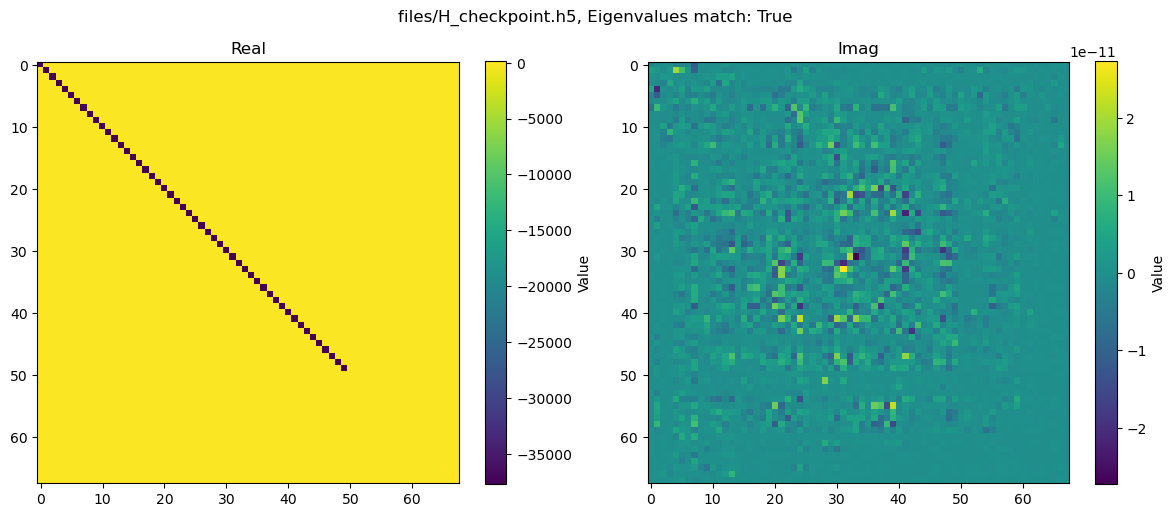

[-4.36557457e-11  2.91038305e-11  1.45519152e-11 -6.54836185e-11
  1.01863407e-10  8.73114914e-11 -7.27595761e-12  2.91038305e-11
  1.45519152e-11  3.63797881e-11 -7.27595761e-12  8.00355338e-11
  6.54836185e-11  1.01863407e-10  1.16415322e-10  4.36557457e-11
  3.63797881e-11 -1.45519152e-11 -6.54836185e-11 -7.27595761e-12
  1.30967237e-10  0.00000000e+00 -7.27595761e-12  1.45519152e-11
 -7.27595761e-12  4.38316050e-13  3.12193466e-11  5.26976240e-11
 -5.96644956e-12  7.41998685e-11 -2.63999933e-11 -1.68887127e-11
  4.14352996e-11  1.39607437e-10]
For Checkpoint file 'files/He_checkpoint.h5', extracted F == recostructed F: True


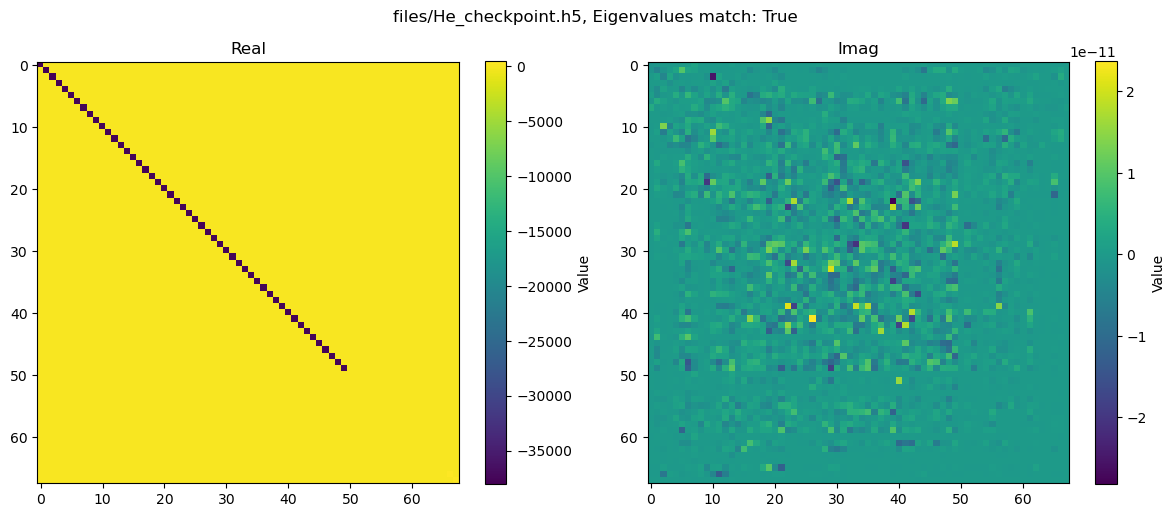

[ 1.45519152e-11 -4.36557457e-11  8.00355338e-11 -3.63797881e-11
  4.36557457e-11  6.54836185e-11 -7.27595761e-11  2.91038305e-11
  2.11002771e-10  3.63797881e-11  2.91038305e-11  7.27595761e-11
  0.00000000e+00  2.40106601e-10  7.27595761e-11  7.27595761e-12
 -2.91038305e-11 -3.63797881e-11  1.45519152e-11 -4.36557457e-11
  2.03726813e-10  1.01863407e-10  1.45519152e-11  4.36557457e-11
  5.09317033e-11  1.80937487e-11  2.58071342e-12 -5.78760373e-11
  9.03106478e-11 -4.34317027e-11 -1.43574042e-12 -8.72368844e-12
  1.12393650e-10  1.05387699e-10]
For Checkpoint file 'files/Ne_checkpoint.h5', extracted F == recostructed F: True


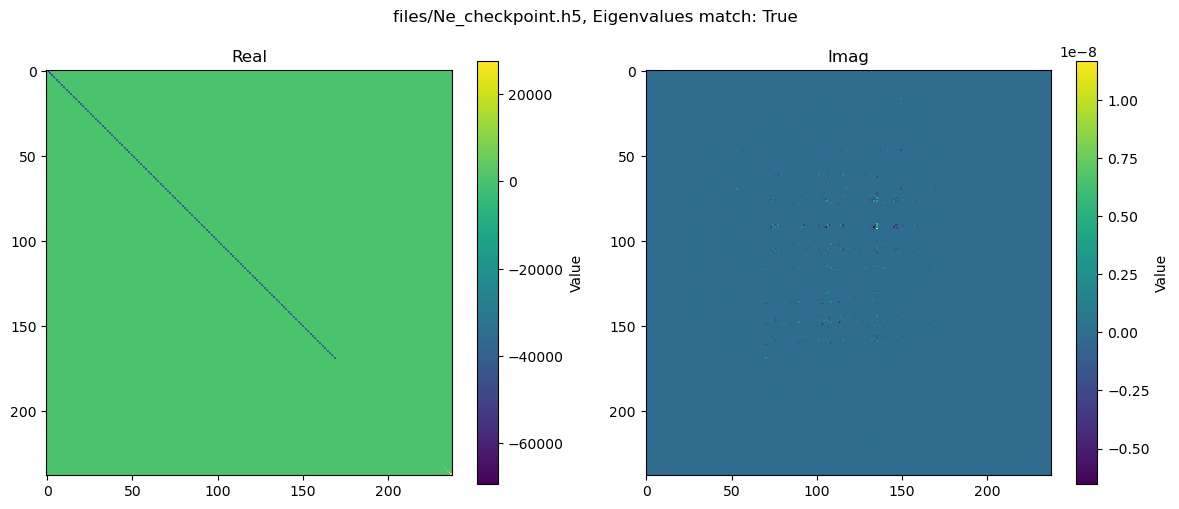

[ 1.45519152e-10  4.65661287e-10  1.96450856e-10  1.01863407e-10
  1.74622983e-10  1.45519152e-10  3.05590220e-10  1.67347025e-10
  7.71251507e-10  9.45874490e-11  7.27595761e-12  4.00177669e-10
  7.71251507e-10  1.09139364e-10  4.43833414e-10  2.64117261e-09
 -3.12866177e-10  1.57160684e-09  1.96450856e-10  8.73114914e-11
  1.45519152e-10  7.27595761e-12  2.91038305e-11  1.15178409e-08
  9.37870936e-09 -5.82076609e-10  2.33558239e-09  6.25732355e-09
  4.00177669e-10  2.18278728e-11  3.10246833e-08 -3.39059625e-09
  2.11002771e-10  8.73114914e-11 -4.36557457e-11  4.72937245e-10
  5.41112968e-08 -5.27506927e-09  2.18788045e-08  1.73095032e-08
  4.58385330e-10  2.18278728e-11 -1.45519152e-10  5.82076609e-10
 -5.67524694e-10  2.97302904e-07 -3.35130608e-08  8.73114914e-11
  8.73114914e-11  7.27595761e-12  7.46586011e-08  1.15614966e-08
  9.14107659e-07 -1.34416041e-07  7.71251507e-10 -1.45519152e-10
 -8.58562998e-10  7.81168637e-07  7.00383680e-08  2.91038305e-11
  3.63797881e-11  7.27595

In [9]:
checkpoint_files = [
    "files/H_checkpoint.h5",
    "files/He_checkpoint.h5",
    "files/Ne_checkpoint.h5",
]

eigenvalue_files = [
    "files/H_F_eigvals_1st_iter.dat",
    "files/He_F_eigvals_1st_iter.dat",
    "files/Ne_F_eigvals_1st_iter.dat",
]

for efile, checkpoint_file in zip(eigenvalue_files, checkpoint_files):
    F_0 = build_4c_one_Fock_from_h5(checkpoint_file)
    S, V, W, T = build_S_V_W_T_from_h5(checkpoint_file)

    with h5py.File(checkpoint_file, "r") as f:
        fockarra = np.asarray(f["result/operators/ao_matrices/ONEFOCK"][()], dtype=np.float64)
        overlap = np.asarray(f["result/operators/ao_matrices/OVERLAP TFFT"][()], dtype=np.float64)

    n_bas = int((np.sqrt(1 + 8 * len(overlap)) - 1) / 2)

    focsquare = fockarra.reshape(4, n_bas, n_bas)  # or manually, but this is convenient
    f0, f1, f2, f3 = focsquare[0], focsquare[1], focsquare[2], focsquare[3]
    Qf = quaternion_to_matrix(f0, f1, f2, f3)

    print(
        f"For Checkpoint file '{checkpoint_file}', extracted F == recostructed F: {np.allclose(Qf, F_0)}"
    )
    X = transformation_matrix(S)

    # plot_map(X)

    F_p = X.T @ F_0 @ X
    np.allclose(F_p, F_p.conj().T)

    e, w = scipy.linalg.eigh(F_p)

    idx = np.argsort(e)
    e = e[idx]
    w = w[:, idx]

    e = [val for i, val in enumerate(e) if i % 2 == 0]

    ref_eigvals = np.loadtxt(efile)

    F_diag = np.linalg.inv(w) @ F_p @ w
    plot_map(
        F_diag,
        title=f"{checkpoint_file}, Eigenvalues match: {np.allclose(ref_eigvals, e)}",
    )
    print(ref_eigvals -e )